In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from sklearn.metrics import confusion_matrix,accuracy_score
import numpy as np
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [15]:
df_cancer=pd.read_csv("../Datasets/BreastCancer.csv",index_col=0)

In [16]:
scaler=StandardScaler()


In [17]:
print(df_cancer.head())

        Clump  UniCell_Size  Uni_CellShape  MargAdh  SEpith  BareN  \
Code                                                                 
61634       5             4              3        1       2      2   
63375       9             1              2        6       4     10   
76389      10             4              7        2       2      8   
95719       6            10             10       10       8     10   
128059      1             1              1        1       2      5   

        BChromatin  NoemN  Mitoses      Class  
Code                                           
61634            2      3        1     Benign  
63375            7      7        2  Malignant  
76389            6      1        1  Malignant  
95719            7     10        7  Malignant  
128059           5      1        1     Benign  


In [19]:
X=df_cancer.drop(columns=["Class"])
Y=df_cancer["Class"]
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=25,stratify=Y)

In [20]:
pca=PCA().set_output(transform="pandas")
x_pca=pca.fit_transform(X)
print(X.shape,x_pca.shape)

(699, 9) (699, 9)


In [21]:
print(np.cumsum(pca.explained_variance_ratio_*100))

[ 68.92148641  76.17490546  82.27277194  86.70847108  90.60818755
  94.06577109  96.59348125  98.86016534 100.        ]


In [22]:
pc_data=x_pca.copy()
pc_data["Class"]=Y

In [23]:
print(pc_data.head())

             pca0      pca1      pca2      pca3      pca4      pca5      pca6  \
Code                                                                            
61634   -1.578410 -1.250952  1.697742  0.419386 -0.627084 -0.357586 -1.309625   
63375    6.685459  4.121834  0.712446  4.106721  4.713119 -0.050167  2.508791   
76389    4.899082  4.102293  5.168775 -0.540668 -1.220417 -1.799109  0.438180   
95719   16.593063 -1.952937 -3.776265 -0.660587  0.611660  2.963865 -0.588300   
128059  -3.294449  2.838637 -2.187085  1.473148 -1.543565 -0.322474  2.338005   

            pca7      pca8      Class  
Code                                   
61634  -0.512075  1.022756     Benign  
63375   1.202568 -0.749758  Malignant  
76389  -1.786111 -1.680400  Malignant  
95719  -1.297223 -0.189840  Malignant  
128059 -0.676226  0.045585     Benign  


<Axes: xlabel='pca0', ylabel='pca1'>

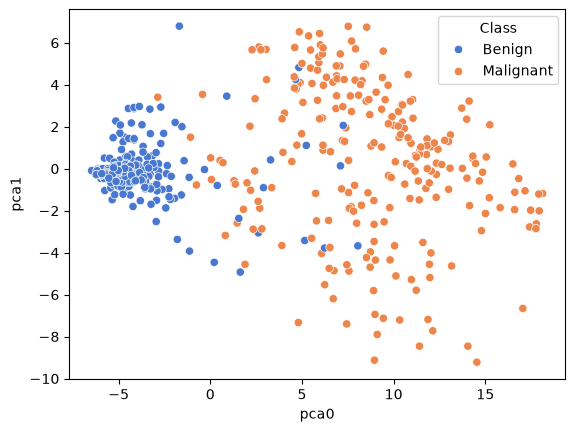

In [24]:
import seaborn as sns
sns.scatterplot(data=pc_data,x="pca0",y="pca1",hue="Class",palette="muted")

<Axes: xlabel='pca1', ylabel='pca2'>

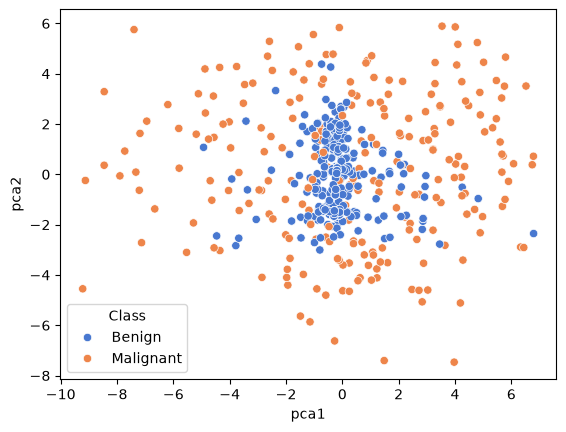

In [25]:
sns.scatterplot(data=pc_data,x="pca1",y="pca2",hue="Class",palette="muted")

<Axes: xlabel='pca2', ylabel='pca3'>

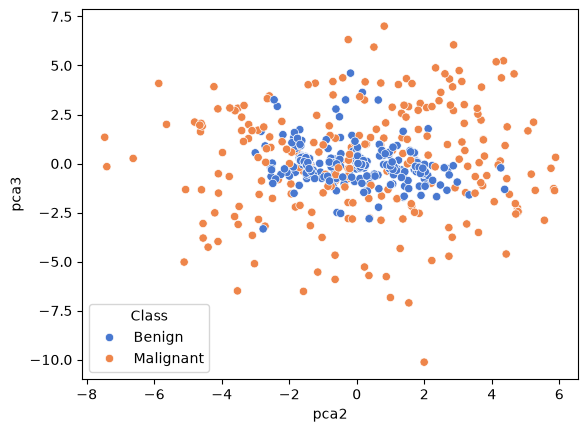

In [26]:
sns.scatterplot(data=pc_data,x="pca2",y="pca3",hue="Class",palette="muted")